# Part 1

### Three datasets are selected and categorised based on their size:
- PROJECT_CHAT.csv is treated as the large dataset.
- REQUESTS_FOR_COMMENT.csv is treated as the medium dataset.
- OTHERS.csv is treated as the small dataset.
### The classification is based on the number of interactions and resulting network size (nodes and edges).

## Task A (network construction)

In [4]:
import pandas as pd
import networkx as nx

def build_network(file_name):
    df = pd.read_csv(file_name)
    
    G = nx.Graph()
    
    grouped = df.groupby(["page_name", "thread_subject"])
    
    for (page, thread), group in grouped:
        users = list(group["username"].dropna().unique())

        for user in users:
            G.add_node(user)

        for i in range(len(users)):
            for j in range(i + 1, len(users)):
                u = users[i]
                v = users[j]

                if G.has_edge(u, v):
                    G[u][v]["weight"] += 1
                else:
                    G.add_edge(u, v, weight=1)
    return df, G

In [6]:
df_large, G_large = build_network("PROJECT_CHAT.csv")
df_medium, G_medium = build_network("REQUESTS_FOR_COMMENT.csv")
df_small, G_small = build_network("OTHERS.csv")

In [7]:
print("Large network")
print("Nodes:", G_large.number_of_nodes())
print("Edges:", G_large.number_of_edges())
print("-----------------")
print("Medium network")
print("Nodes:", G_medium.number_of_nodes())
print("Edges:", G_medium.number_of_edges())
print("-----------------")
print("Small network")
print("Nodes:", G_small.number_of_nodes())
print("Edges:", G_small.number_of_edges())

Large network
Nodes: 4136
Edges: 40255
-----------------
Medium network
Nodes: 888
Edges: 27569
-----------------
Small network
Nodes: 2493
Edges: 11076


### Explanation:
- Nodes represent unique Wikidata users. Edges represent social connections between users who both commented in the same thread within the same page.
- The raw data is stored in a pandas DataFrame, while the network is represented as an undirected NetworkX graph. Edge weights are used to record repeated co-participation between users.
- The dataset is grouped by page name and thread subject. For each group, unique users are extracted and all user pairs are connected. If the same pair appears again in another discussion group, the edge weight is increased.

## Task B (network metrics)

In [12]:
import numpy as np

def compute_metrics(G):
    metrics = {}

    degrees = [d for n, d in G.degree()]
    metrics["avg_degree"] = np.mean(degrees)
    
    metrics["clustering"] = nx. average_clustering(G)

    metrics["density"] = nx.density(G)

    metrics["num_components"] = nx.number_connected_components(G)

    largest_cc_nodes = max(nx.connected_components(G), key=len)
    largest_cc = G.subgraph(largest_cc_nodes).copy()

    metrics["largest_cc_size"] = largest_cc.number_of_nodes()
    metrics["avg_path_length"] = nx.average_shortest_path_length(largest_cc)

    return metrics

In [14]:
metrics_large = compute_metrics(G_large)
metrics_medium = compute_metrics(G_medium)
metrics_small = compute_metrics(G_small)

print("Large:", metrics_large)
print("Medium:", metrics_medium)
print("Small:", metrics_small)

Large: {'avg_degree': 19.46566731141199, 'clustering': 0.6670824027288833, 'density': 0.0047075374392773865, 'num_components': 203, 'largest_cc_size': 3924, 'avg_path_length': 2.740578381551284}
Medium: {'avg_degree': 62.09234234234234, 'clustering': 0.7818077578450452, 'density': 0.07000264074672193, 'num_components': 54, 'largest_cc_size': 833, 'avg_path_length': 2.0867375796472434}
Small: {'avg_degree': 8.885679903730445, 'clustering': 0.3988830878644716, 'density': 0.0035656821443541113, 'num_components': 437, 'largest_cc_size': 2002, 'avg_path_length': 3.0723958699970693}


In [15]:
# random network
def random_graph(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    p = (2 * m) / (n * (n-1))

    return nx.erdos_renyi_graph(n,p)

In [16]:
G_rand_large = random_graph(G_large)
G_rand_medium = random_graph(G_medium)
G_rand_small = random_graph(G_small)

In [17]:
rand_large = compute_metrics(G_rand_large)
rand_medium = compute_metrics(G_rand_medium)
rand_small = compute_metrics(G_rand_small)

print("Random Large:", rand_large)
print("Random Medium:", rand_medium)
print("Random Small:", rand_small)

Random Large: {'avg_degree': 19.403288201160542, 'clustering': 0.0046509900983630345, 'density': 0.004692451801973529, 'num_components': 1, 'largest_cc_size': 4136, 'avg_path_length': 3.0862487984114475}
Random Medium: {'avg_degree': 62.4009009009009, 'clustering': 0.07030475585271775, 'density': 0.07035050834374397, 'num_components': 1, 'largest_cc_size': 888, 'avg_path_length': 1.9413601876961517}
Random Small: {'avg_degree': 8.931407942238268, 'clustering': 0.00340995612731706, 'density': 0.0035840320795498663, 'num_components': 2, 'largest_cc_size': 2492, 'avg_path_length': 3.8112988459900263}


In [18]:
import matplotlib.pyplot as plt
import collections

def plot_degree_distribution(G1, G2, G3, titles):
    graphs = [G1, G2, G3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, G, title in zip(axes, graphs, titles):
        degrees = [d for _, d in G.degree()]
        degree_count = collections.Counter(degrees)
        deg, cnt = zip(*sorted(degree_count.items()))

        ax.bar(deg, cnt)
        ax.set_title(title)
        ax.set_xlabel("Degree")
        ax.set_ylabel("Count")
 
    plt.tight_layout()
    plt.show()

In [19]:
import matplotlib.pyplot as plt
import collections

def plot_degree_distribution(G1, G2, G3, titles):
    graphs = [G1, G2, G3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, G, title in zip(axes, graphs, titles):
        degrees = [d for _, d in G.degree()]
        degree_count = collections.Counter(degrees)
        deg, cnt = zip(*sorted(degree_count.items()))

        ax.bar(deg, cnt)
        ax.set_title(title)
        ax.set_xlabel("Degree")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

In [20]:
def plot_real_vs_random(real_graphs, rand_graphs, labels):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for ax, G, label in zip(axes[0], real_graphs, labels):
        degrees = [d for _, d in G.degree()]
        degree_count = collections.Counter(degrees)
        deg, cnt = zip(*sorted(degree_count.items()))

        ax.bar(deg, cnt)
        ax.set_title(f"Real {label}")
        ax.set_xlabel("Degree")
        ax.set_ylabel("Count")

    for ax, G, label in zip(axes[1], rand_graphs, labels):
        degrees = [d for _, d in G.degree()]
        degree_count = collections.Counter(degrees)
        deg, cnt = zip(*sorted(degree_count.items()))

        ax.bar(deg, cnt)
        ax.set_title(f"Random {label}")
        ax.set_xlabel("Degree")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

ERROR! Session/line number was not unique in database. History logging moved to new session 14


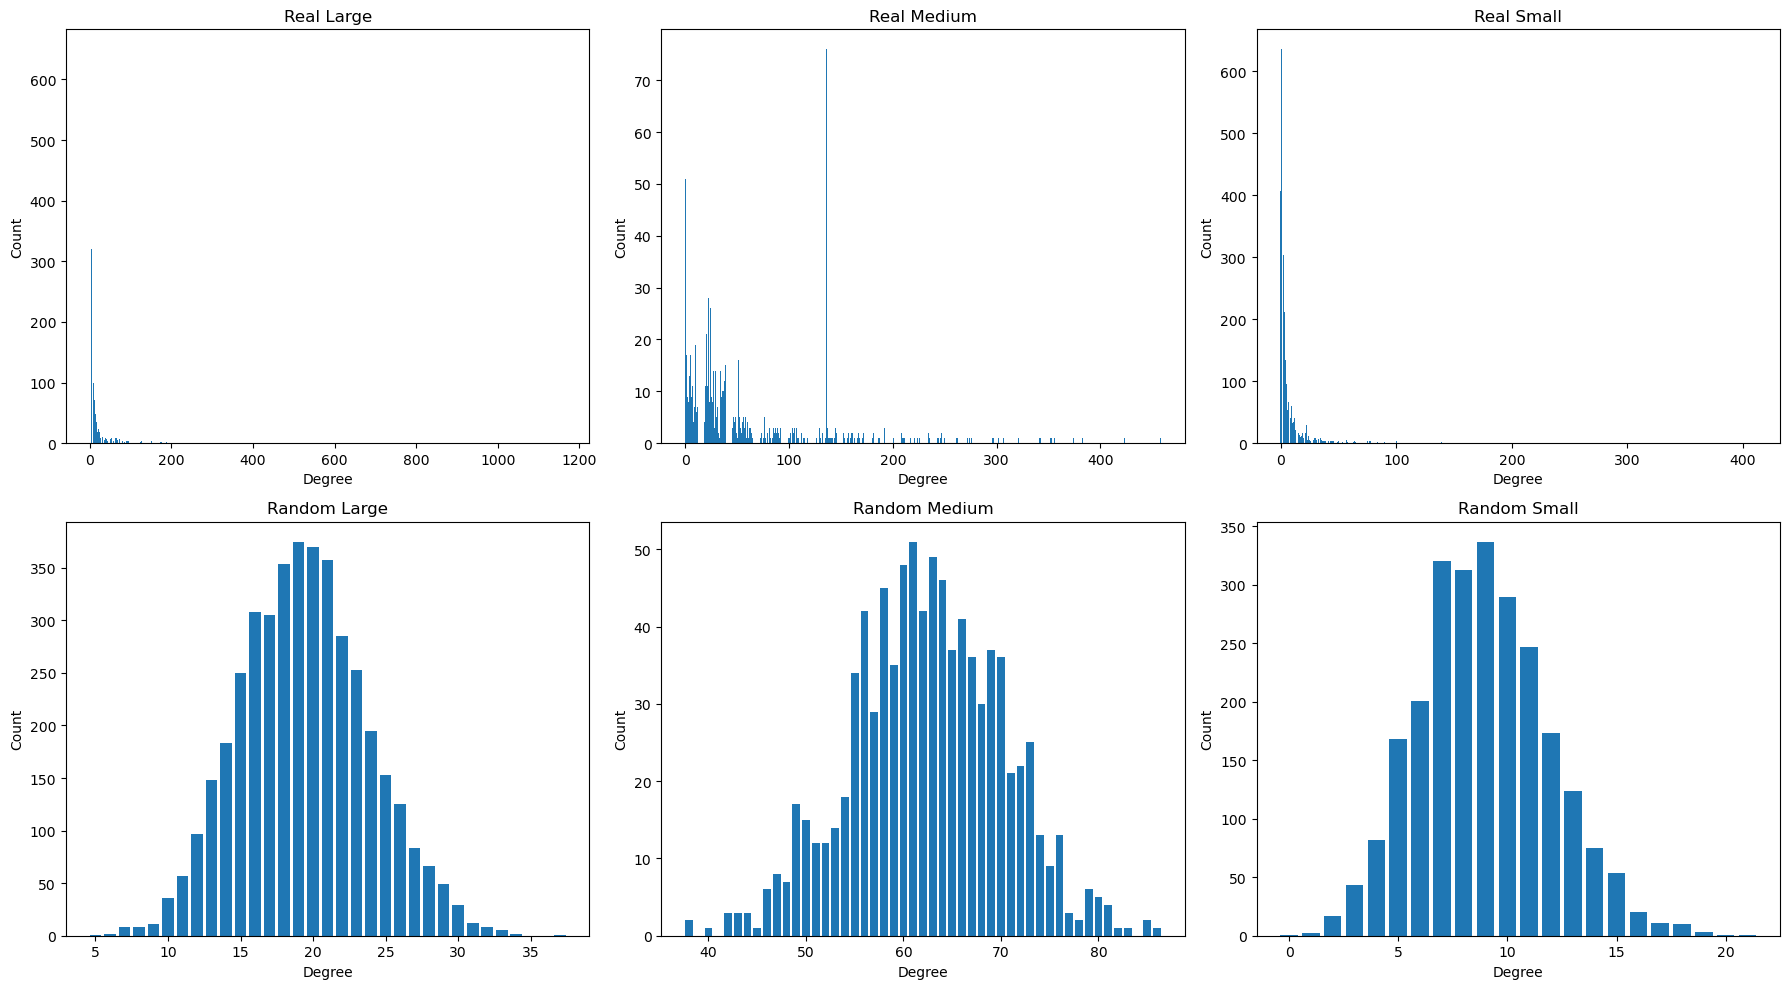

In [21]:
plot_real_vs_random(
    [G_large, G_medium, G_small],
    [G_rand_large, G_rand_medium, G_rand_small],
    ["Large", "Medium", "Small"]
)

### Summarising the results:

In [23]:
import pandas as pd

df_metrics = pd.DataFrame({
    "Dataset": ["Large", "Medium", "Small"],
    "Avg Degree (Real)": [
        metrics_large["avg_degree"],
        metrics_medium["avg_degree"],
        metrics_small["avg_degree"]
    ],
    "Clustering (Real)": [
        metrics_large["clustering"],
        metrics_medium["clustering"],
        metrics_small["clustering"]
    ],
    "Path Length (Real)": [
        metrics_large["avg_path_length"],
        metrics_medium["avg_path_length"],
        metrics_small["avg_path_length"]
    ],
    "Density (Real)":[
        metrics_large["density"],
        metrics_medium["density"],
        metrics_small["density"]
    ],
    "Components (Real)":[
        metrics_large["num_components"],
        metrics_medium["num_components"],
        metrics_small["num_components"]
    ],
    "Avg Degree (Random)":[
        rand_large["avg_degree"],
        rand_medium["avg_degree"],
        rand_small["avg_degree"]
    ],
    "Clustering (Random)":[
        rand_large["clustering"],
        rand_medium["clustering"],
        rand_small["clustering"]
    ],
    "Path Length (Random)": [
        rand_large["avg_path_length"],
        rand_medium["avg_path_length"],
        rand_small["avg_path_length"]
    ],
    "Density (Random)": [
        rand_large["density"],
        rand_medium["density"],
        rand_small["density"]
    ],
    "Components (Random)": [
        rand_large["num_components"],
        rand_medium["num_components"],
        rand_small["num_components"]
    ]
})

df_metrics

,Dataset,Avg Degree (Real),Clustering (Real),Path Length (Real),Density (Real),Components (Real),Avg Degree (Random),Clustering (Random),Path Length (Random),Density (Random),Components (Random)
0,Large,19.465667,0.667082,2.740578,0.004708,203,19.403288,0.004651,3.086249,0.004692,1
1,Medium,62.092342,0.781808,2.086738,0.070003,54,62.400901,0.070305,1.941360,0.070351,1
2,Small,8.885680,0.398883,3.072396,0.003566,437,8.931408,0.003410,3.811299,0.003584,2


### Explanation:
- The Large and Medium networks show high clustering (0.667 and 0.782), short average path lengths (2.74 and 2.09). The Small network has lower clustering (0.399) and is heavily fragmented with 437 connected components. Moreover, the real networks exhibit highly right-skewed distributions, while the random graphs show approximately bell-shaped distributions.
- Compared with a random graph of similar size, the real network has much higher clustering and many more connected components, while the average path length remains broadly similar. This means the network is not random: it is more locally structured and socially grouped.
- The results suggest that editors do not interact uniformly across the whole network. Instead, they tend to form discussion clusters around shared threads, but a few highly connected users help link different parts of the network, giving it some small-world-like properties.

## Task C (epidemic models)

In [26]:
import random

def check_distance_and_similarity(G, name, seed=42):
    random.seed(seed)
    nodes = list(G.nodes())
    u, v = random.sample(nodes, 2)

    try:
        dist = nx.shortest_path_length(G, u, v)
        path = nx.shortest_path(G, u, v)
        connected = True
    except:
        dist = float("inf")
        path = []
        connected = False

    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    common_neighbors = neighbors_u & neighbors_v

    print(f"=== {name} ===")
    print("User A:", u)
    print("User B:", v)
    print("Connected:", connected)
    print("Shortest path:", dist)
    print("Path:", path if connected else "No path")
    print("Common neighbors:", len(common_neighbors))
    print()

    return {
        "u": u,
        "v": v,
        "dist": dist,
        "path": path,
        "common_neighbors": list(common_neighbors)
    }

In [27]:
selected = {}

selected["Large"] = check_distance_and_similarity(G_large, "Large network")
selected["Medium"] = check_distance_and_similarity(G_medium, "Medium network")
selected["Small"] = check_distance_and_similarity(G_small, "Small network")

=== Large network ===
User A: Pan Brerus
User B: Kneiphof
Connected: True
Shortest path: 3
Path: ['Pan Brerus', 'Vogone', 'Tpt', 'Kneiphof']
Common neighbors: 0

=== Medium network ===
User A: Ralgis
User B: Ptolusque
Connected: True
Shortest path: 2
Path: ['Ralgis', 'Ymblanter', 'Ptolusque']
Common neighbors: 14

=== Small network ===
User A: Hogweard
User B: Iwan.Aucamp
Connected: False
Shortest path: inf
Path: No path
Common neighbors: 0



### Short Explanation:
A short path suggests easier spread between the two users. Common neighbours indicate overlapping local connections. If the path is infinite, it means the users are disconnected.

In [29]:
def get_priority_nodes(G, suspicious_info, top_n=10):
    u = suspicious_info["u"]
    v = suspicious_info["v"]

    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))

    common = neighbors_u & neighbors_v
    union_neighbors = neighbors_u | neighbors_v

    priority_candidates = []

    for node in union_neighbors:
        score = 0
        score += G.degree(node)
        if node in common:
            score += 10
        priority_candidates.append((node, score))

    priority_candidates = sorted(priority_candidates, key=lambda x: x[1], reverse=True)

    print(f"Suspicious users: {u}, {v}")
    print("Top priority nodes to check next:")
    print(priority_candidates[:top_n])
    print()

    return priority_candidates[:top_n]

In [30]:
priority_large = get_priority_nodes(G_large, selected["Large"], top_n=5)
priority_medium = get_priority_nodes(G_medium, selected["Medium"], top_n=5)
priority_small = get_priority_nodes(G_small, selected["Small"], top_n=5)

Suspicious users: Pan Brerus, Kneiphof
Top priority nodes to check next:
[('Ymblanter', 628), ('Stryn', 549), ('Zolo', 359), ('Tpt', 266), ('Vogone', 203)]

Suspicious users: Ralgis, Ptolusque
Top priority nodes to check next:
[('Rschen7754', 468), ('Ymblanter', 428), ('ArthurPSmith', 423), ('Stryn', 393), ('TomT0m', 384)]

Suspicious users: Hogweard, Iwan.Aucamp
Top priority nodes to check next:
[('Jura1', 358), ('ArthurPSmith', 223), ('VIGNERON', 190), ('TomT0m', 174), ('Pigsonthewing', 148)]



### Short Explanation:
The priority list is based on users who are directly connected to the suspicious editors. Common neighbours of both suspicious users are especially important, because they may already be exposed from both sides. Among these nearby users, those with higher degree are prioritised because they can potentially spread controversial behaviour to more editors. This makes the priority list more targeted than simply selecting the highest-degree users in the whole network.

In [32]:
!pip install ndlib
import ndlib.models.epidemics as ep
import ndlib.models.ModelConfig as mc
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend

def run_diffusion_from_suspicious(G, title, suspicious_info):
    u = suspicious_info["u"]
    v = suspicious_info["v"]

    model = ep.SIRModel(G)
    config = mc.Configuration()

    config.add_model_parameter("beta", 0.1)
    config.add_model_parameter("gamma", 0.05)
    config.add_model_initial_configuration("Infected", [u, v])

    model.set_initial_status(config)

    iterations = model.iteration_bunch(20)
    trends = model.build_trends(iterations)

    viz = DiffusionTrend(model, trends)
    viz.plot()

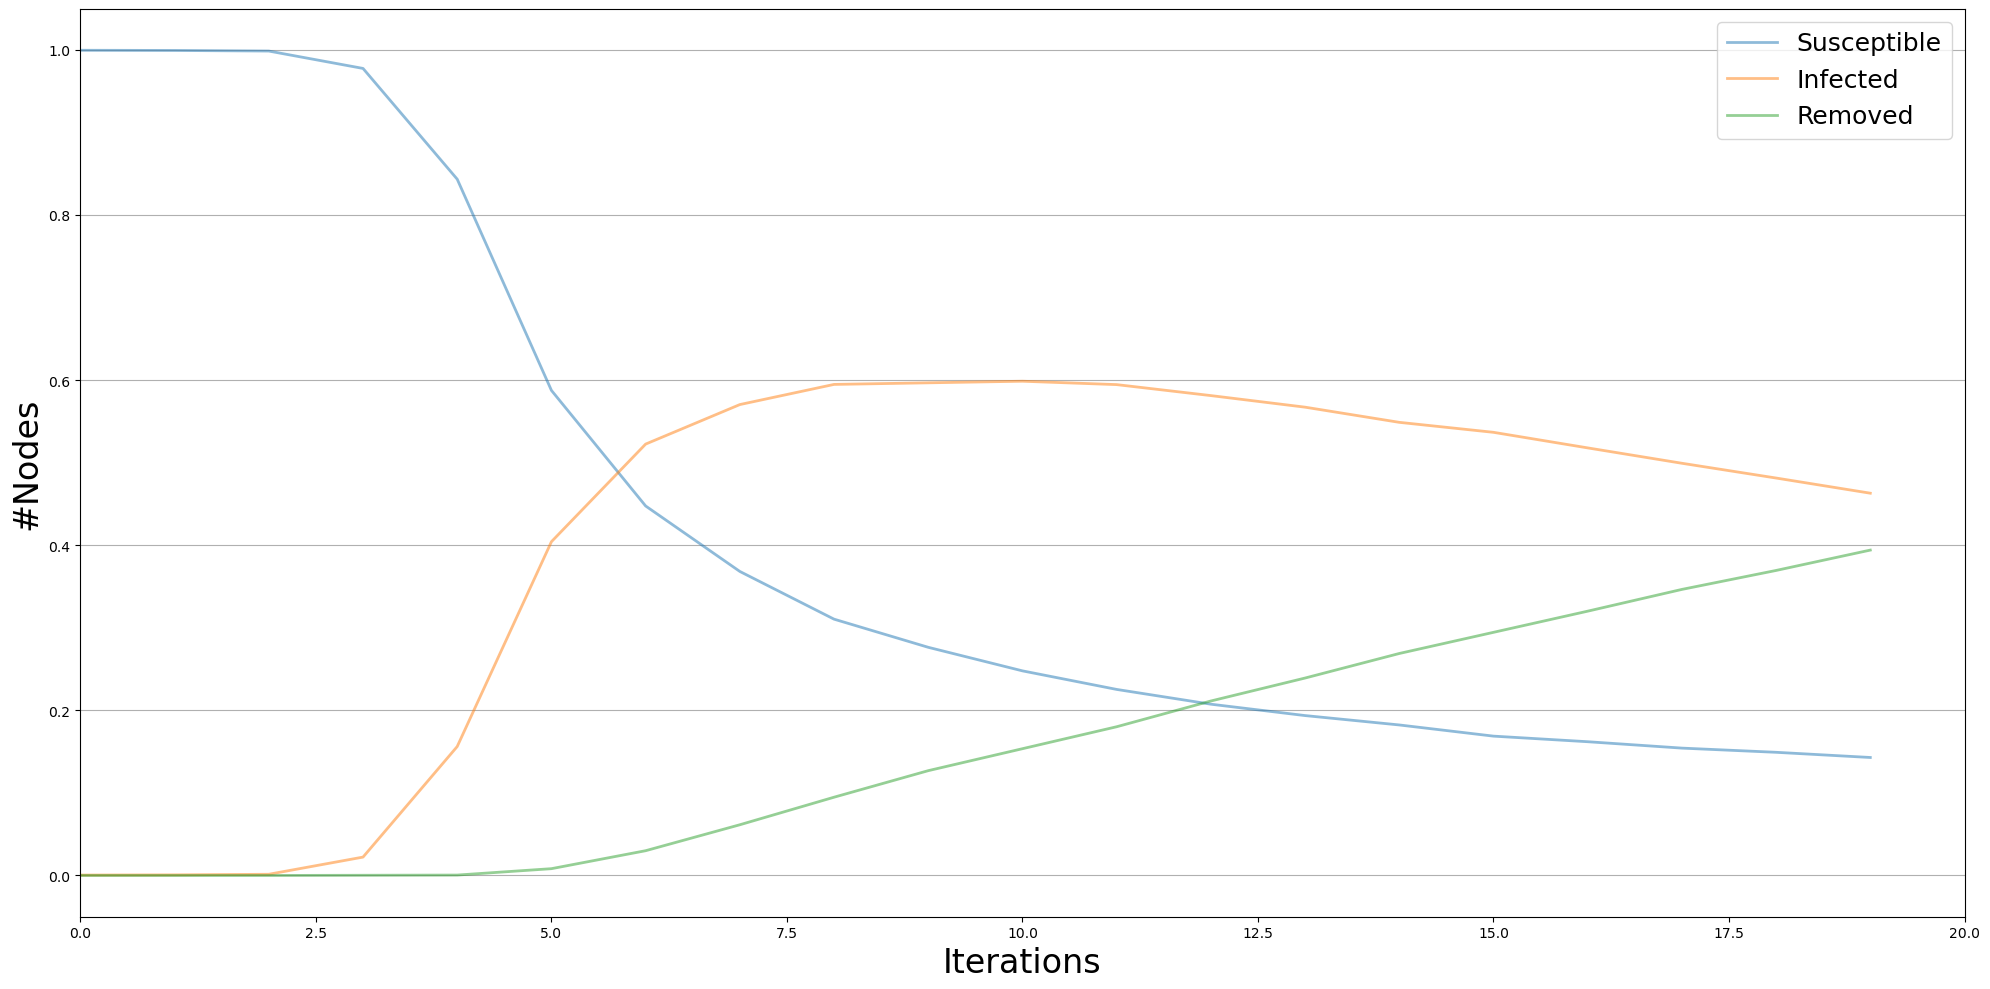

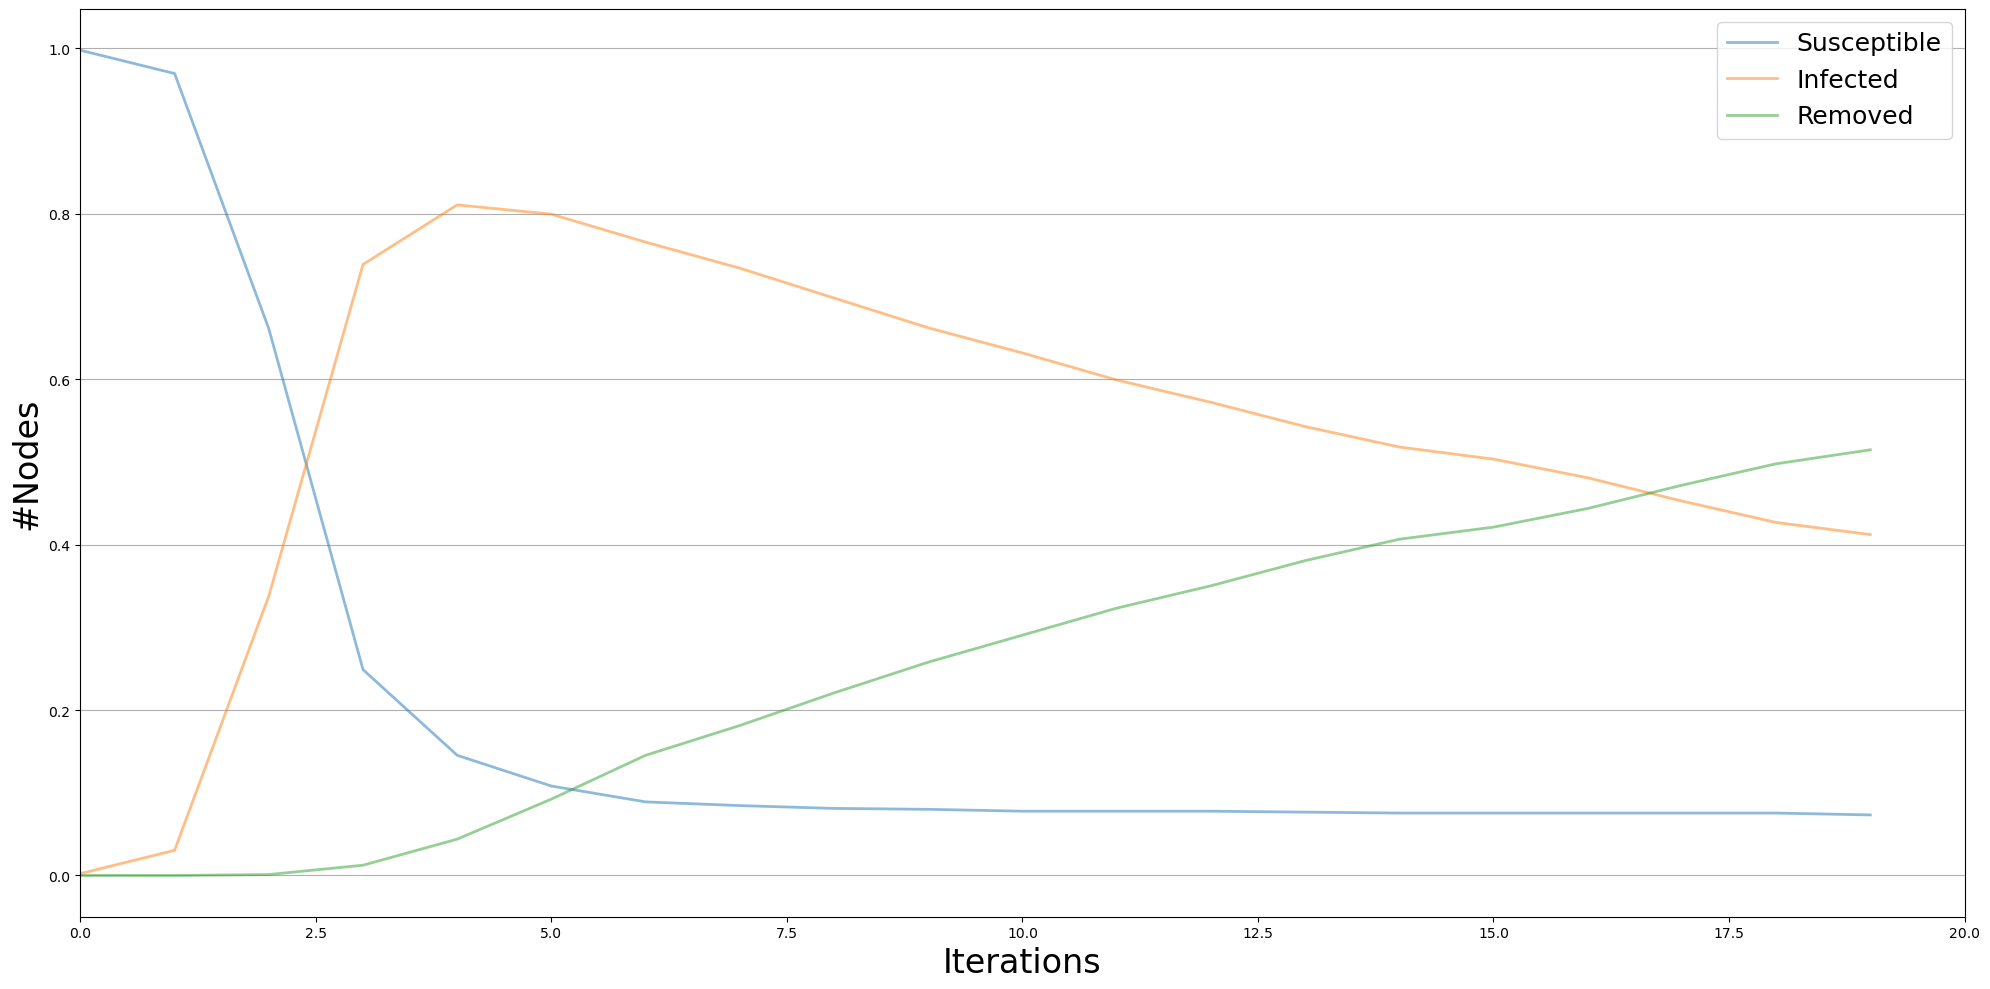

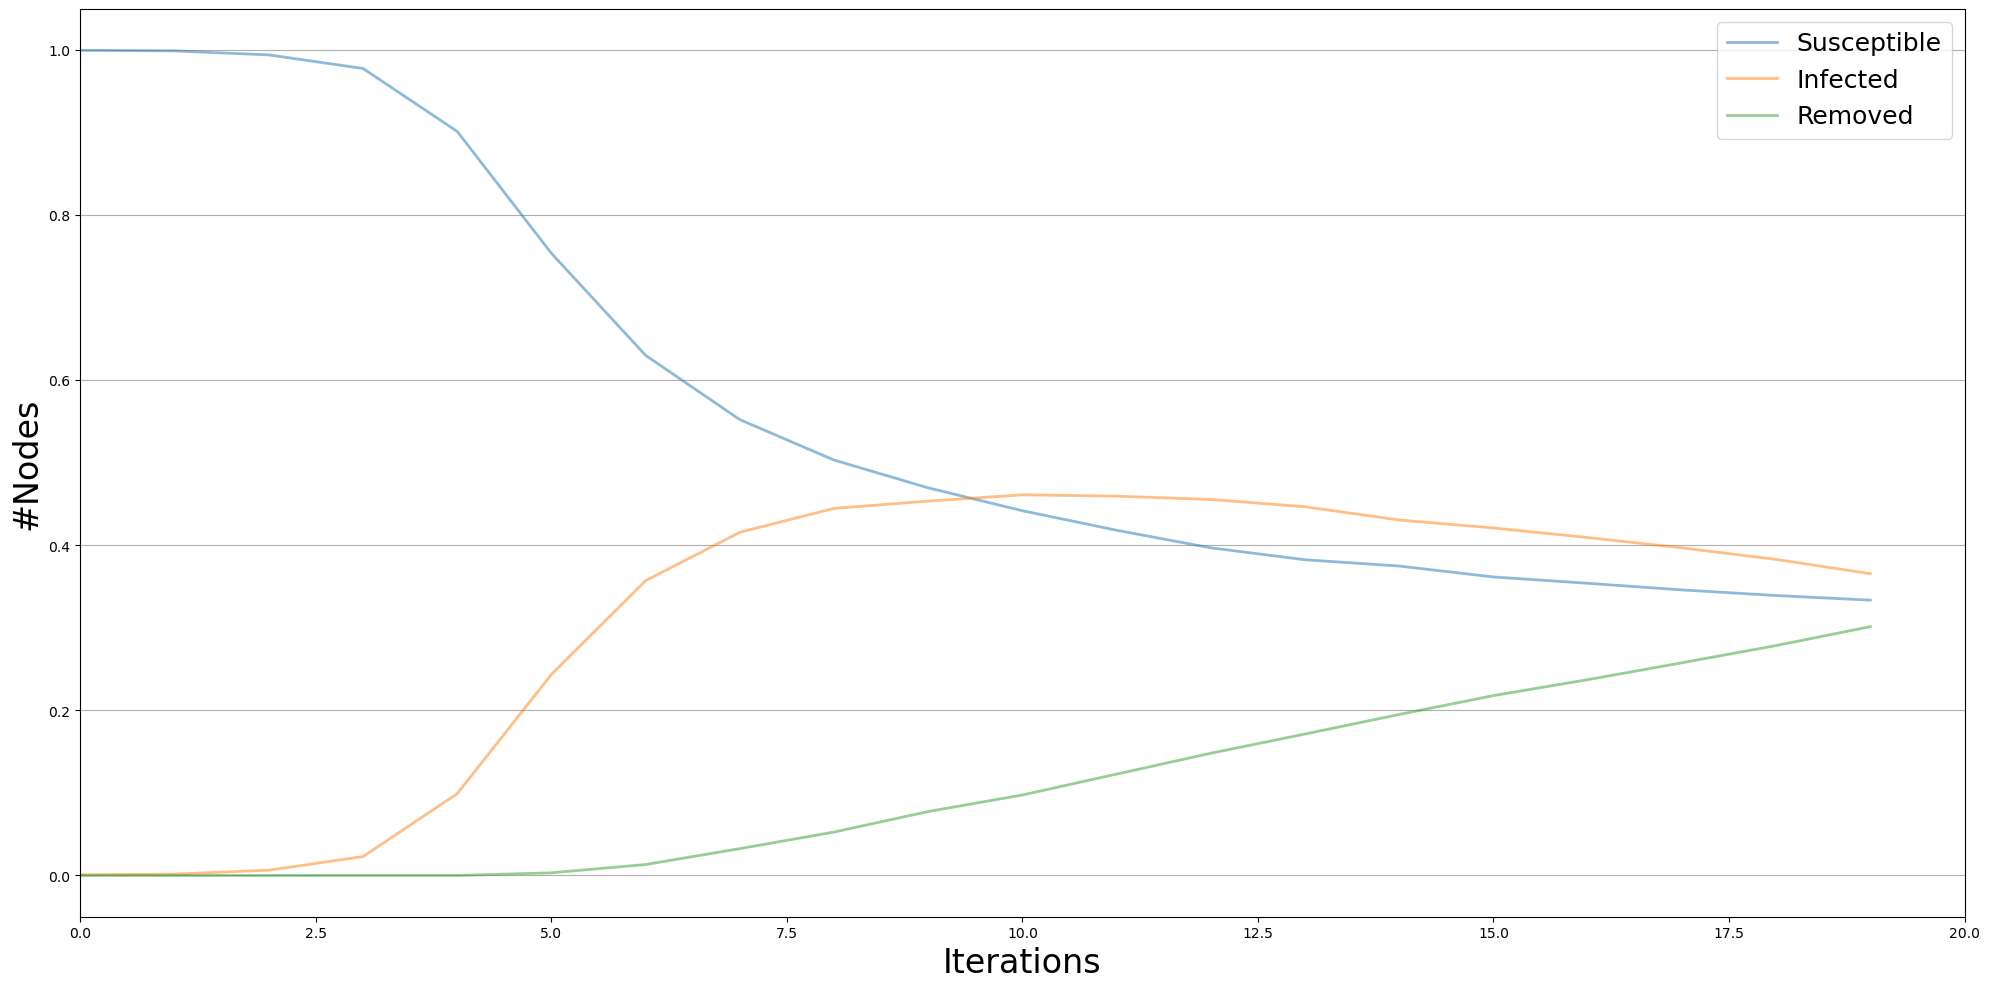

In [33]:
run_diffusion_from_suspicious(G_large, "Large network", selected["Large"])
run_diffusion_from_suspicious(G_medium, "Medium network", selected["Medium"])
run_diffusion_from_suspicious(G_small, "Small network", selected["Small"])

### Short Explanation:
To match the coursework scenario, the diffusion model starts from the two suspicious editors identified earlier instead of random infected nodes. I use the SIR model, where editors can be susceptible, infected (engaging in controversial behaviour), or recovered (no longer spreading it). This fits the idea that trolling can spread for a while but does not last forever. Beta shows how likely an infected editor influences a neighbour, while gamma controls how quickly it stops. A quick rise and fall in infections suggests fast but temporary spread, and a limited spread indicates a more fragmented or less connected network.

## Final Discussion:
More connected networks show faster spread, while fragmented networks limit propogation. The larger graphs are closer to the small-world side because they combine short paths with local clustering.

The more disconnected graph is less small-world. These results are also affected by the network definition, since linking users who comment in the same page and thread can create dense local clusters. The SIR simulations show a similar result. Networks with shorter paths and higher clustering showed a faster rise in the Infected curve before recovery took over, while in the more fragmented network, it only spread to a smaller number of nodes.